In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style = 'darkgrid', palette='husl')

In [6]:
df = pd.read_csv('D:/ai-projects/mlops-churn-pipeline/data/churn_raw.csv')

print({df.shape})

display(df.head(3))
display(df.dtypes)


{(7043, 21)}


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
# null check
nulls = df.isnull().sum()
print("Nulls per column:")
print(nulls[nulls>0] if nulls.any() else "No nulls found (yet)")



Nulls per column:
No nulls found (yet)


In [8]:
#total charges column is in String and not fload, possible data quality issue
print(f"\nTotalCharges dtype: {df['TotalCharges'].dtype}")



TotalCharges dtype: object


In [10]:
print(df['TotalCharges'].value_counts().tail(5))

TotalCharges
1990.5    1
7362.9    1
346.45    1
306.6     1
108.15    1
Name: count, dtype: int64


In [11]:
# Fix it

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nNull after coerce: {df['TotalCharges'].isnull().sum()}")




Null after coerce: 11


In [12]:
df['TotalCharges'].fillna(0, inplace=True)
print("TotalCharges fixed")


TotalCharges fixed


C:\Users\Admin\AppData\Local\Temp\ipykernel_24444\2440248644.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [13]:
#checl if the null works

print(f"\nNull: {df['TotalCharges'].isnull().sum()}")


Null: 0


In [14]:
## check churn distribution

df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [20]:
print(df['Churn_num'].sum())

print(df['Churn_num'].sum()/df['Churn_num'].count())

1869
0.2653698707936959


In [18]:
churn_rate = df['Churn_num'].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

Overall churn rate: 26.5%


In [21]:
print(f"Churned:  {df['Churn_num'].sum()} customers")
print(f"Retained:  {(df['Churn_num']==0).sum()} customers")

Churned:  1869 customers
Retained:  5174 customers


In [22]:
print(f"\nClass ratio: 1 churner for every {(1/churn_rate - 1):.1f} retained customers")


Class ratio: 1 churner for every 2.8 retained customers


In [23]:
dummy_accuracy = 1 - churn_rate

print(f"\n Dummy model accuracy where model always predicts no: {dummy_accuracy:.1%}")
print("This is why we use ROC-AUC")


 Dummy model accuracy where model always predicts no: 73.5%
This is why we use ROC-AUC


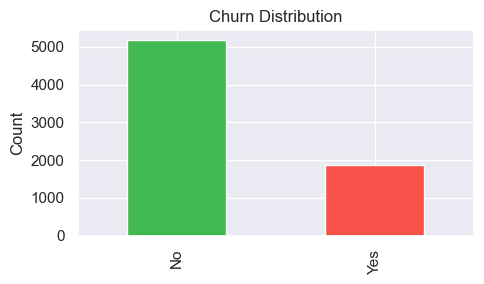

In [24]:
fig, ax = plt.subplots(figsize = (5,3))

df['Churn'].value_counts().plot(kind='bar', ax = ax, color = ['#3fb950','#f85149'])
ax.set_title('Churn Distribution')
ax.set_xlabel('') 
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


In [25]:
# CONTRACT TYPE — most powerful predictor
contract_churn = df.groupby('Contract')['Churn_num'].mean().sort_values(ascending=False)
print("Churn rate by contract type:")
print(contract_churn.apply(lambda x: f"{x:.1%}"))

Churn rate by contract type:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn_num, dtype: object


In [26]:
# TENURE
churned_tenure = df[df['Churn_num']==1]['tenure'].mean()
retained_tenure = df[df['Churn_num']==0]['tenure'].mean()
print(f"\nAvg tenure — Churned: {churned_tenure:.1f} months | Retained: {retained_tenure:.1f} months")



Avg tenure — Churned: 18.0 months | Retained: 37.6 months


In [27]:
# MONTHLY CHARGES
churned_mc = df[df['Churn_num']==1]['MonthlyCharges'].mean()
retained_mc = df[df['Churn_num']==0]['MonthlyCharges'].mean()
print(f"Avg monthly charges — Churned: ${churned_mc:.2f} | Retained: ${retained_mc:.2f}")



Avg monthly charges — Churned: $74.44 | Retained: $61.27


In [28]:
# INTERNET SERVICE
internet_churn = df.groupby('InternetService')['Churn_num'].mean()
print(f"\nChurn by internet service:\n{internet_churn.apply(lambda x: f'{x:.1%}')}")



Churn by internet service:
InternetService
DSL            19.0%
Fiber optic    41.9%
No              7.4%
Name: Churn_num, dtype: object


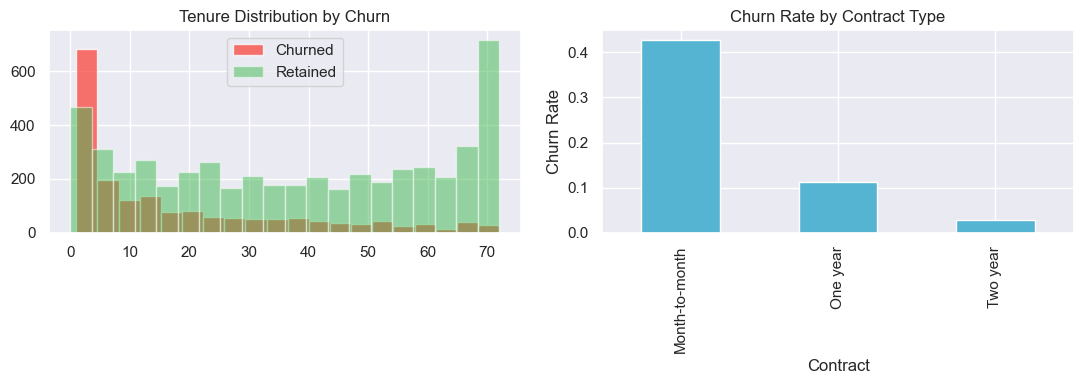

In [30]:
# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(11,4))
df[df['Churn']=='Yes']['tenure'].hist(ax=axes[0], bins=20, color='#f85149', alpha=0.8, label='Churned')
df[df['Churn']=='No']['tenure'].hist(ax=axes[0], bins=20, color='#3fb950', alpha=0.5, label='Retained')
axes[0].set_title('Tenure Distribution by Churn'); axes[0].legend()
contract_churn.plot(kind='bar', ax=axes[1], color='#56b4d3')
axes[1].set_title('Churn Rate by Contract Type'); axes[1].set_ylabel('Churn Rate')
plt.tight_layout(); plt.show()

In [31]:
# Drop the helper column and save
df.drop(columns=['Churn_num'], inplace=True)
df.to_csv('../data/churn_clean.csv', index=False)
print("✓ Clean dataset saved to data/churn_clean.csv")
print(f"Shape: {df.shape}")

✓ Clean dataset saved to data/churn_clean.csv
Shape: (7043, 21)
